### 1. Cell 1. 데이터 로드 및 기본 구조 확인

- train.csv는 891개의 행과 12개의 열로 구성되어 있습니다.

- Survived는 우리가 예측해야 할 타겟(Target) 변수입니다.

- Age, Cabin, Embarked 컬럼에 결측치(Null)가 존재하는 것을 확인할 수 있으며, 이후 전처리 단계에서 처리가 필요함을 시사합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
train = pd.read_csv(r"C:\Users\a0916\dartb\DartB_Titanic\train.csv")
test = pd.read_csv(r"C:\Users\a0916\dartb\DartB_Titanic\test.csv")

# 데이터의 크기와 상위 5개 행 확인
print(f"Train data shape: {train.shape}")
print(train.head())

# 각 컬럼의 데이터 타입과 Non-Null 개수 확인
print("-" * 30)
print(train.info())

Train data shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450 

### 2. Cell 2. 결측치(Missing Values) 분포 시각화

- Cabin: 데이터의 약 77%가 비어있습니다. 너무 많은 결측치가 있어 분석에서 제외하거나 특수한 처리가 필요해 보입니다.

- Age: 약 20%의 결측치가 존재합니다. 생존에 중요한 변수일 가능성이 높으므로 평균이나 중앙값 등으로 채워야 합니다.

- Embarked: 단 2건의 결측치가 있어 최빈값으로 채우기에 적합합니다.

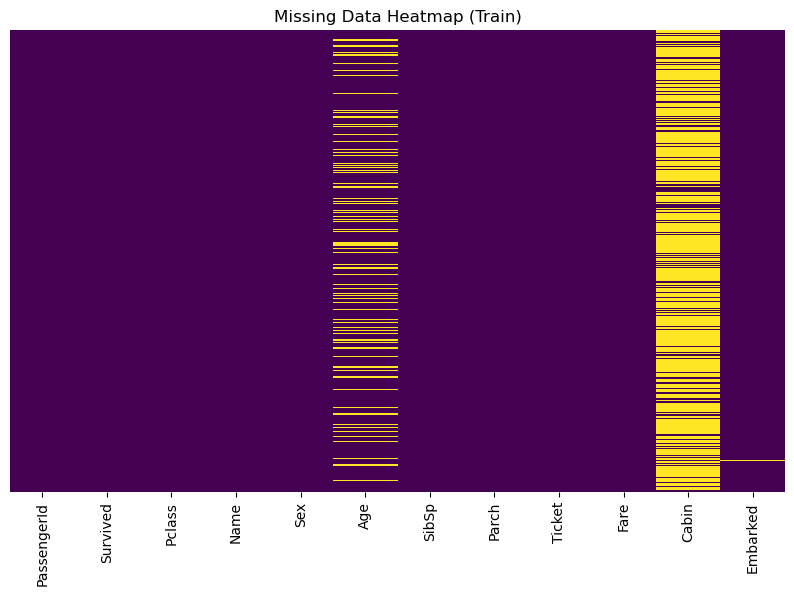


[컬럼별 결측치 합계]
Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


In [2]:
# 결측치 시각화 
plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap (Train)')
plt.show()

# 상세 수치 확인
print("\n[컬럼별 결측치 합계]")
print(train.isnull().sum().sort_values(ascending=False))

### 3. Cell 3. 타겟 변수(Survived) 분포 확인

- 생존자와 사망자의 비율이 얼마나 차이가 나는지(데이터 불균형 확인) 파악합니다.
- 전체 승객 중 생존자는 약 38%, 사망자는 약 62% 로 확인되었습니다.

사망자(0) 비율: 61.62%
생존자(1) 비율: 38.38%


C:\Users\a0916\AppData\Local\Temp\ipykernel_7876\481015786.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train, palette='pastel')


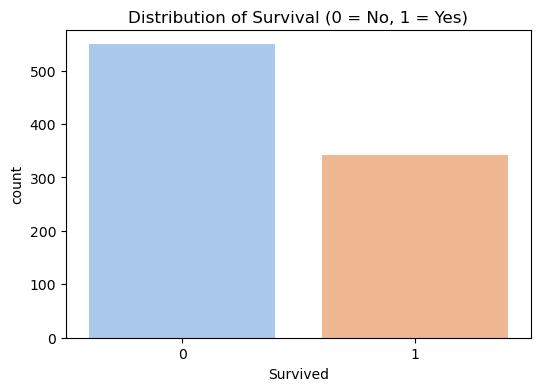

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=train, palette='pastel')
plt.title('Distribution of Survival (0 = No, 1 = Yes)')

# 생존율 계산
survive_rate = train['Survived'].value_counts(normalize=True) * 100
print(f"사망자(0) 비율: {survive_rate[0]:.2f}%")
print(f"생존자(1) 비율: {survive_rate[1]:.2f}%")
plt.show()

### 4. Cell 4. 범주형 변수(Sex, Pclass)와 생존의 관계
- 가장 중요한 생존 요인으로 꼽히는 성별과 티켓 등급을 분석합니다.

- Sex: 여성의 생존율이 남성에 비해 압도적으로 높습니다. 이는 생존 예측의 핵심 피처임을 보여줍니다.

- Pclass: 1등급(고급) 승객의 생존율이 가장 높고, 3등급 승객의 생존율이 가장 낮습니다. 사회 경제적 지위가 생존에 영향을 주었음을 알 수 있습니다.

C:\Users\a0916\AppData\Local\Temp\ipykernel_7876\358034170.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=train, ax=ax[0], palette='magma')
C:\Users\a0916\AppData\Local\Temp\ipykernel_7876\358034170.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=train, ax=ax[1], palette='viridis')


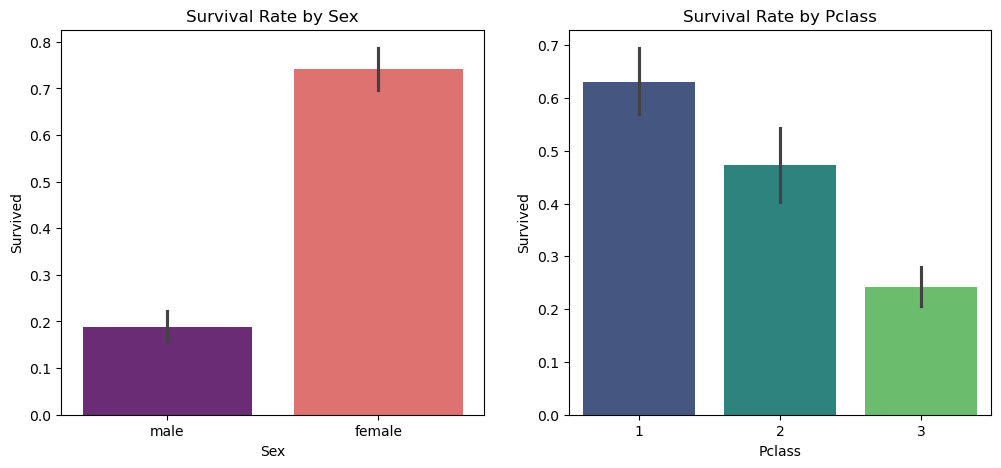

Survived    0    1  All
Sex                    
female     81  233  314
male      468  109  577
All       549  342  891


In [4]:
# 성별 및 티켓 등급별 생존율 시각화
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x='Sex', y='Survived', data=train, ax=ax[0], palette='magma')
ax[0].set_title('Survival Rate by Sex')

sns.barplot(x='Pclass', y='Survived', data=train, ax=ax[1], palette='viridis')
ax[1].set_title('Survival Rate by Pclass')

plt.show()

# 교차 테이블로 수치 확인
print(pd.crosstab(train['Sex'], train['Survived'], margins=True))

### 5. Cell 5. 수치형 변수(Age, Fare) 분포 및 왜도 확인

- 연령대별 분포와 요금의 왜도(치우침)를 확인하여 변환이 필요한지 검토합니다.

- Age: 비교적 정규분포에 가깝지만, 어린아이(0~10세) 구간이 살짝 튀어나와 있습니다.

- Fare: 왜도(Skewness)가 4.79로 매우 높습니다. 
대부분의 승객이 저렴한 티켓을 샀고 일부만 매우 비싼 요금을 지불했다는 뜻으로 파악됩니다.

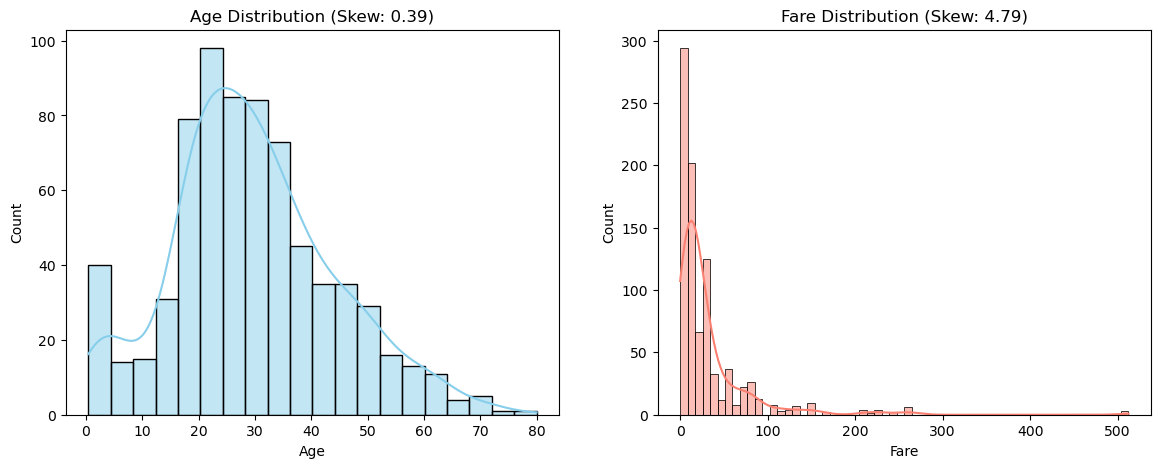

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 연령 분포 (Age)
sns.histplot(train['Age'].dropna(), kde=True, ax=ax[0], color='skyblue')
ax[0].set_title(f'Age Distribution (Skew: {train["Age"].skew():.2f})')

# 요금 분포 (Fare)
sns.histplot(train['Fare'], kde=True, ax=ax[1], color='salmon')
ax[1].set_title(f'Fare Distribution (Skew: {train["Fare"].skew():.2f})')

plt.show()

### 6. 가족 동승자(SibSp, Parch) 통합 분석
- 형제/배우자 수와 부모/자녀 수를 합쳐 '가족 규모'의 영향을 봅니다.

- 가족이 2~4명인 경우 생존율이 가장 높습니다.

- 반면, 혼자 탄 경우(1명)나 5명 이상의 대가족인 경우에는 오히려 생존율이 낮아지는 경향을 보입니다. 

- 이는 이후 IsAlone과 같은 새로운 변수를 만드는 근거로 활용하였습니다

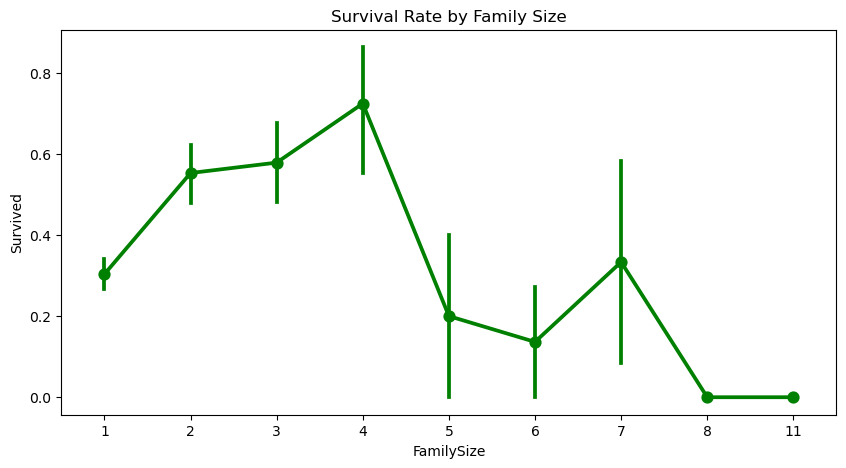

In [6]:
# 파생 변수 생성: FamilySize = SibSp + Parch + 1 (본인 포함)
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

plt.figure(figsize=(10, 5))
sns.pointplot(x='FamilySize', y='Survived', data=train, color='green')
plt.title('Survival Rate by Family Size')
plt.show()

*동승자가 아예 없는 '나홀로 승객'은 위급 상황에서 서로 도울 사람이 없어서 생존율이 낮은 게 아닐까*

- 결론: 혼자 탄 승객은 위급 상황에서 도움을 줄 가족이 없었거나, 상대적으로 탈출 순위가 밀렸을 가능성이 큽니다.

C:\Users\a0916\AppData\Local\Temp\ipykernel_7876\3225565839.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IsAlone', y='Survived', data=train, palette='coolwarm')


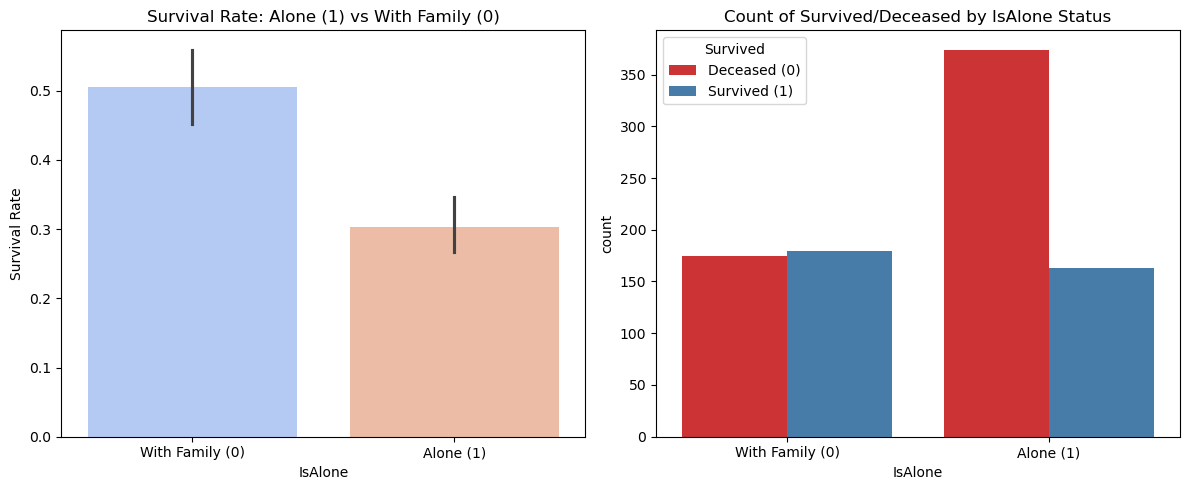

가족 동반 승객 생존율: 50.56%
나홀로 승객 생존율: 30.35%


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파생 변수 생성
# 가족 수(FamilySize)가 1명이면 혼자(IsAlone=1), 아니면 가족 동반(IsAlone=0)
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['IsAlone'] = 0
train.loc[train['FamilySize'] == 1, 'IsAlone'] = 1

# 2. 시각화 설정
plt.figure(figsize=(12, 5))

# [왼쪽 그래프] 그룹별 생존율 (평균)
plt.subplot(1, 2, 1)
sns.barplot(x='IsAlone', y='Survived', data=train, palette='coolwarm')
plt.title('Survival Rate: Alone (1) vs With Family (0)')
plt.xticks([0, 1], ['With Family (0)', 'Alone (1)'])
plt.ylabel('Survival Rate')

# [오른쪽 그래프] 그룹별 생존/사망자 수 비교
plt.subplot(1, 2, 2)
sns.countplot(x='IsAlone', hue='Survived', data=train, palette='Set1')
plt.title('Count of Survived/Deceased by IsAlone Status')
plt.xticks([0, 1], ['With Family (0)', 'Alone (1)'])
plt.legend(title='Survived', labels=['Deceased (0)', 'Survived (1)'])

plt.tight_layout()
plt.show()

# 3. 실제 수치 확인
print(f"가족 동반 승객 생존율: {train[train['IsAlone'] == 0]['Survived'].mean():.2%}")
print(f"나홀로 승객 생존율: {train[train['IsAlone'] == 1]['Survived'].mean():.2%}")

### 7. Cell 7. 변수 간 상관관계 분석 (Heatmap)
- 피처들 사이의 선형적 관계를 파악하여 다중공선성 문제를 체크합니다.

- Pclass와 Fare는 강한 음의 상관관계(-0.55)를 보입니다. 당연하게도 높은 등급(작은 숫자)일수록 요금이 비싸기 때문입니다.

- SibSp와 Parch는 양의 상관관계(0.41)가 있어 함께 움직이는 경향이 있으므로, 앞선 단계처럼 FamilySize로 통합하는 전략이 유효함을 뒷받침합니다.

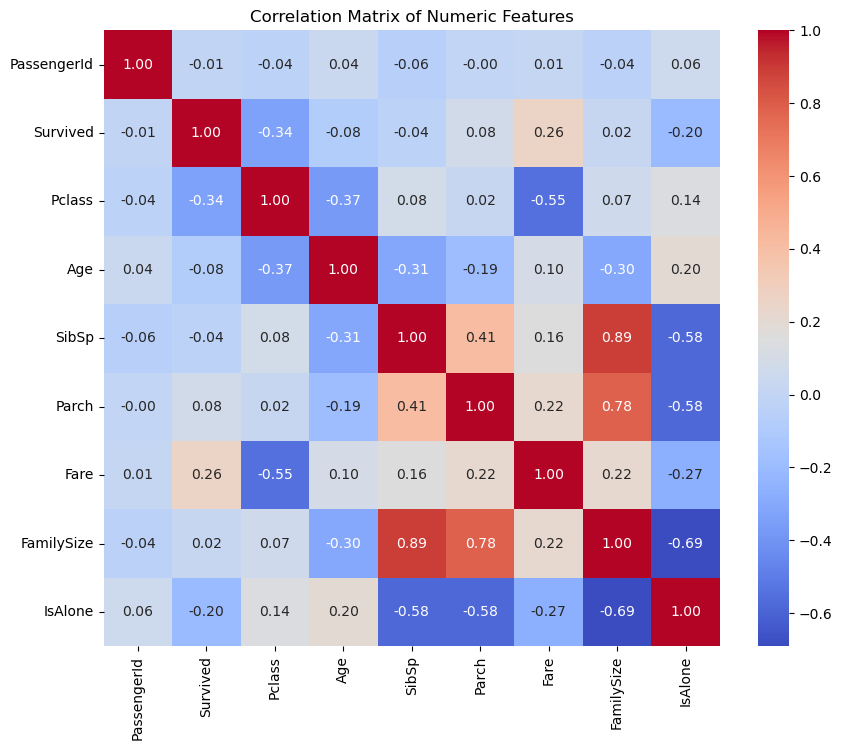

In [8]:
# 수치형 데이터만 선택하여 상관계수 산출
numeric_train = train.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_train.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### 8. 데이터 이상치(Outliers) 탐지

- 나이(Age): 70~80세 이상의 고령 승객들이 이상치로 나타나지만, 이는 충분히 발생 가능한 범위 내의 데이터이므로 삭제하지 않고 유지합니다.

- 요금(Fare): $500 이상의 요금을 낸 승객이 소수 존재하며, 전체적인 데이터 분포와 매우 동떨어져 있습니다. 
- 따라서 이러한 이상치는 모델이 특정 데이터에 과적합(Overfitting)되게 할 수 있으므로 처리가 필요합니다.

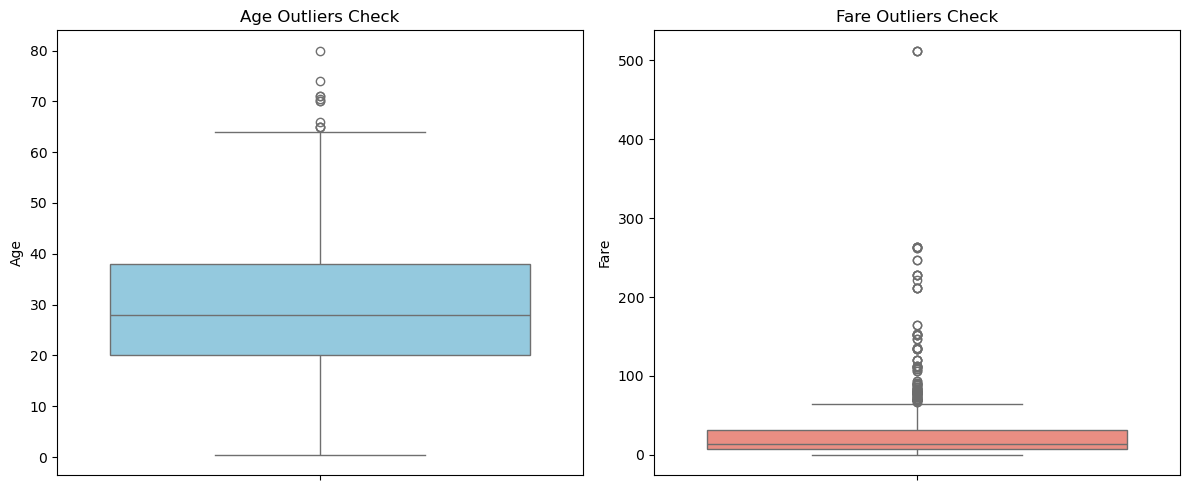

In [9]:
plt.figure(figsize=(12, 5))

# [왼쪽] 나이(Age) 이상치 확인
plt.subplot(1, 2, 1)
sns.boxplot(y=train['Age'], color='skyblue')
plt.title('Age Outliers Check')

# [오른쪽] 요금(Fare) 이상치 확인
plt.subplot(1, 2, 2)
sns.boxplot(y=train['Fare'], color='salmon')
plt.title('Fare Outliers Check')

plt.tight_layout()
plt.show()

### 9. 요금(Fare) 데이터의 왜도(Skewness) 해결

- 로그를 취하면 큰 값은 작게 만들고, 작은 값들 사이의 간격은 상대적으로 넓혀주는 효과가 있어 분포를 중앙으로 모아줍니다

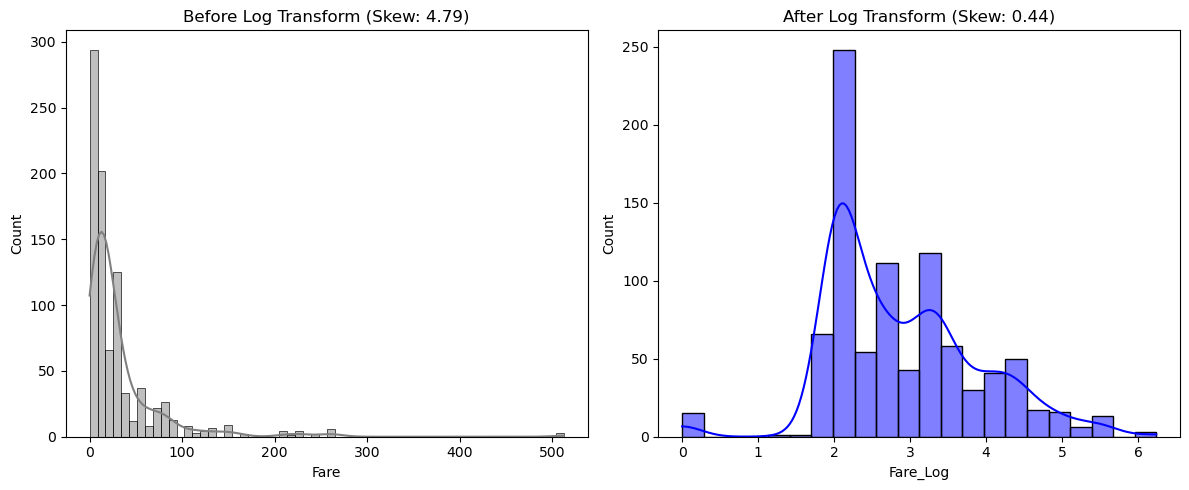

In [10]:
# 로그 변환 수행 (0인 값이 있을 수 있으므로 np.log1p 또는 조건문 사용)
train['Fare_Log'] = train['Fare'].map(lambda i: np.log(i) if i > 0 else 0)

plt.figure(figsize=(12, 5))

# 변환 전 히스토그램
plt.subplot(1, 2, 1)
sns.histplot(train['Fare'], kde=True, color='gray')
plt.title(f'Before Log Transform (Skew: {train["Fare"].skew():.2f})')

# 변환 후 히스토그램
plt.subplot(1, 2, 2)
sns.histplot(train['Fare_Log'], kde=True, color='blue')
plt.title(f'After Log Transform (Skew: {train["Fare_Log"].skew():.2f})')

plt.tight_layout()
plt.show()

### 10. 호칭(Title) 추출을 통한 사회적 지위 분석

C:\Users\a0916\AppData\Local\Temp\ipykernel_7876\3429232393.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Title', y='Survived', data=train, palette='muted', order=['Mr', 'Miss', 'Mrs', 'Master', 'Rare'])


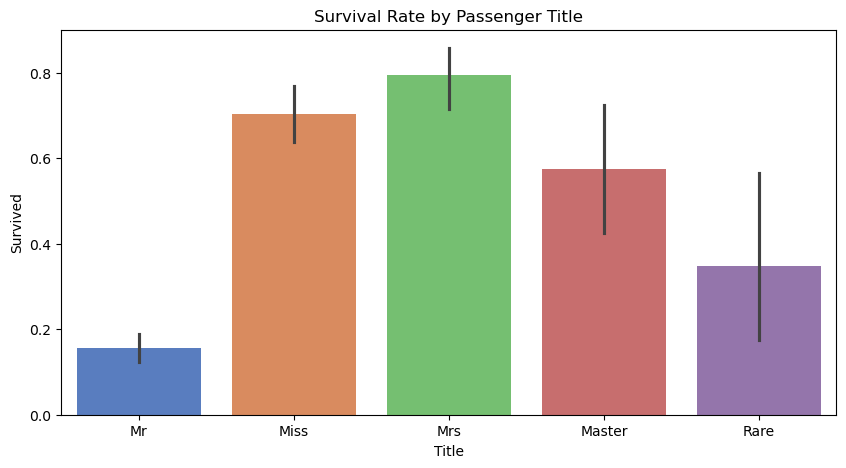

In [11]:
# 이름에서 호칭(Mr, Mrs, Miss 등) 추출
train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 희귀 호칭 통합 (Royalty, Officer 등)
train['Title'] = train['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train['Title'] = train['Title'].replace(['Mlle', 'Ms'], 'Miss')
train['Title'] = train['Title'].replace('Mme', 'Mrs')

# 호칭별 생존율 시각화
plt.figure(figsize=(10, 5))
sns.barplot(x='Title', y='Survived', data=train, palette='muted', order=['Mr', 'Miss', 'Mrs', 'Master', 'Rare'])
plt.title('Survival Rate by Passenger Title')
plt.show()

### 11. 승선 항구별 생존율 시각화

- C (Cherbourg): 이 항구에서 탄 승객의 생존율이 가장 높습니다. (비싼 요금을 낸 1등석 승객이 많았을 가능성이 큼)

- S (Southampton): 가장 많은 승객이 탔지만 생존율은 가장 낮습니다.

- 항구(C, Q, S) 사이에는 명확한 서열이 없으므로, 숫자로 순서를 매기는 Label Encoding보다는 One-Hot Encoding을 적용하여 각 항구를 독립적인 변수로 만드는 것이 안전

C:\Users\a0916\AppData\Local\Temp\ipykernel_7876\1772840865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=train, palette='viridis')


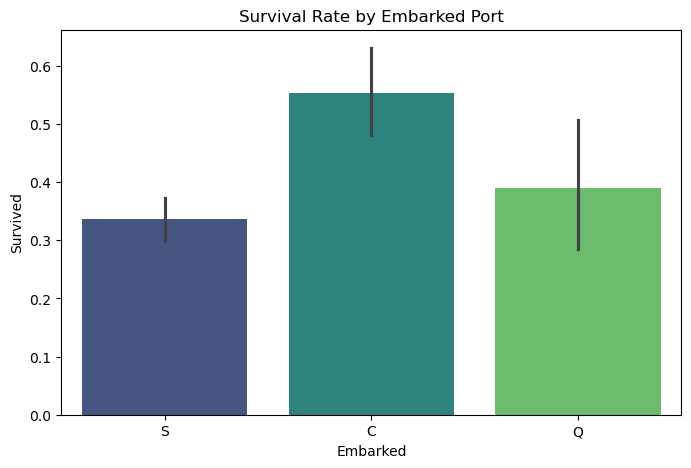

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Embarked', y='Survived', data=train, palette='viridis')
plt.title('Survival Rate by Embarked Port')
plt.show()

# 항구별 승객 수 확인
print(train['Embarked'].value_counts())

### 12. 새로운 피처를 포함한 상관계수 재확인

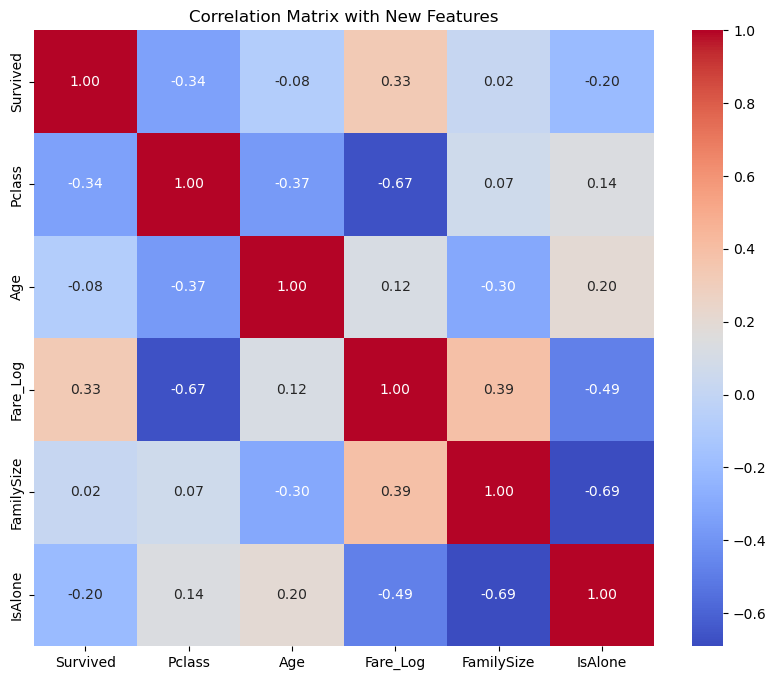

In [13]:
# 수치형 변수 + 새로 만든 수치형 변수들 선택
features_to_check = ['Survived', 'Pclass', 'Age', 'Fare_Log', 'FamilySize', 'IsAlone']
plt.figure(figsize=(10, 8))
sns.heatmap(train[features_to_check].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix with New Features')
plt.show()

### 13. 추가 EDA 1. `Age` 결측치 대체 기준 탐색

- `Age`는 결측이 많기 때문에 **어떤 기준으로 채울지** 먼저 확인합니다.
- 전체 중앙값으로 한 번에 채우기보다, **`Title + Pclass` 기준 중앙값**이 더 자연스러운지 살펴봅니다.
- 이 결과는 이후 `Age` 보간과 연령대 파생변수 생성의 근거가 됩니다.


[Title + Pclass별 Age 중앙값]
Pclass     1     2     3
Title                   
Master   4.0   1.0   4.0
Miss    30.0  24.0  18.0
Mr      40.0  31.0  26.0
Mrs     40.0  32.0  31.0
Rare    48.5  46.5   NaN

[Title별 Age 결측 비율]
Title
Mr        23.02%
Miss      19.46%
Mrs       13.49%
Master     10.0%
Rare       4.35%
Name: Age, dtype: object


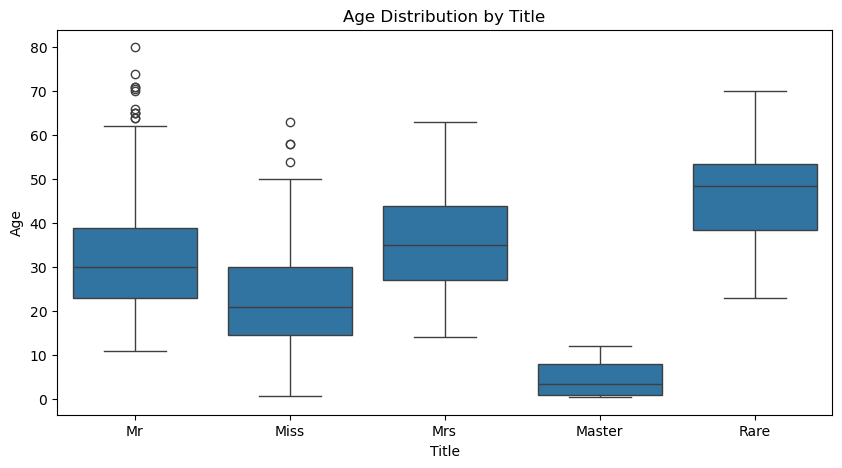

In [14]:
# Age 결측치 대체 기준 탐색
# - 승객 집단별(호칭, 객실등급) 나이 분포가 다른지 확인합니다.

# Title + Pclass 기준 Age 중앙값 확인
age_group_median = (
    train.groupby(['Title', 'Pclass'])['Age']
         .median()
         .unstack()
)

print("[Title + Pclass별 Age 중앙값]")
print(age_group_median)

# Title별 Age 결측 비율 확인
age_missing_by_title = (
    train.groupby('Title')['Age']
         .apply(lambda s: s.isna().mean())
         .sort_values(ascending=False)
)

print("\n[Title별 Age 결측 비율]")
print((age_missing_by_title * 100).round(2).astype(str) + '%')

# 호칭별 나이 분포 시각화
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x='Title', y='Age', order=['Mr', 'Miss', 'Mrs', 'Master', 'Rare'])
plt.title('Age Distribution by Title')
plt.xlabel('Title')
plt.ylabel('Age')
plt.show()


### 14. 추가 EDA 2. 연령대(`AgeBand`)별 생존율 확인

- 먼저 EDA용으로만 `Age`를 임시 보간한 뒤, 연령대를 나누어 생존율을 봅니다.
- 특히 **성별과 연령대가 함께 작용하는지** 확인하면, 상호작용 피처 설계에 도움이 됩니다.


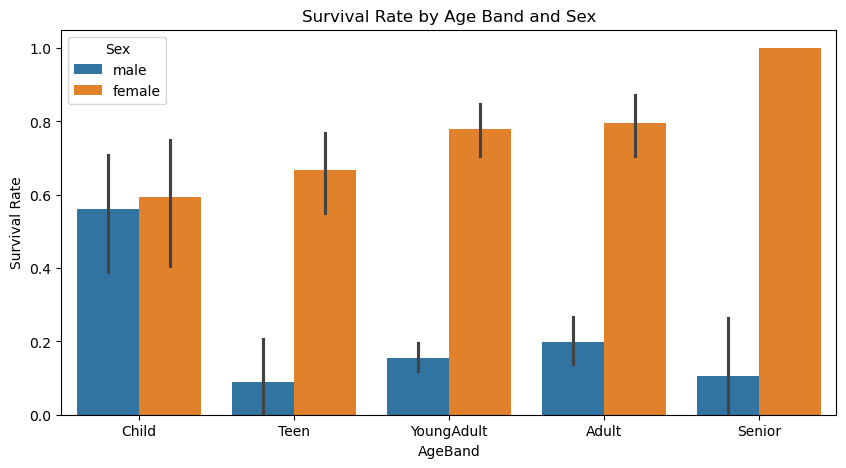

[연령대별 생존율]
AgeBand
Child         0.575342
Teen          0.475728
Adult         0.406250
YoungAdult    0.330490
Senior        0.227273
Name: Survived, dtype: float64


In [15]:
# EDA용 임시 Age 보간
# 1) Title + Pclass 중앙값으로 우선 보간
age_fill_map = train.groupby(['Title', 'Pclass'])['Age'].median()

train['Age_for_eda'] = train['Age'].copy()

for (title, pclass), median_age in age_fill_map.items():
    mask = (
        train['Age_for_eda'].isna() &
        (train['Title'] == title) &
        (train['Pclass'] == pclass)
    )
    train.loc[mask, 'Age_for_eda'] = median_age

# 2) 남은 결측치는 전체 중앙값으로 마무리
train['Age_for_eda'] = train['Age_for_eda'].fillna(train['Age'].median())

# 연령대 구간화
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']

train['AgeBand'] = pd.cut(
    train['Age_for_eda'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# 성별과 함께 연령대별 생존율 확인
plt.figure(figsize=(10, 5))
sns.barplot(data=train, x='AgeBand', y='Survived', hue='Sex')
plt.title('Survival Rate by Age Band and Sex')
plt.xlabel('AgeBand')
plt.ylabel('Survival Rate')
plt.show()

print("[연령대별 생존율]")
print(train.groupby('AgeBand', observed=False)['Survived'].mean().sort_values(ascending=False))


### 15. 추가 EDA 3. `Cabin` 결측 자체가 정보인지 확인

- `Cabin`은 결측이 많아 원본을 그대로 쓰기 어렵습니다.
- 하지만 **객실 정보가 기록되어 있는지 여부(`HasCabin`) 자체**가 생존과 관련될 수 있으므로,
  이를 하나의 피처 후보로 볼 수 있는지 확인합니다.


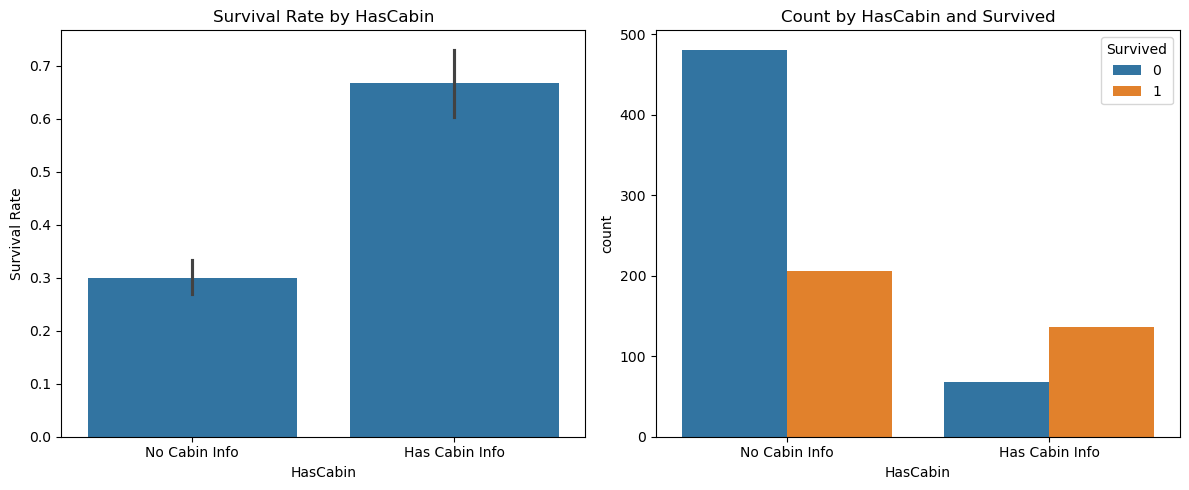

[HasCabin 교차표]
Survived    0    1  All
HasCabin               
0         481  206  687
1          68  136  204
All       549  342  891


In [16]:
# Cabin 결측 여부 자체를 피처로 사용할 수 있는지 확인
train['HasCabin'] = train['Cabin'].notna().astype(int)

plt.figure(figsize=(12, 5))

# [왼쪽] Cabin 정보 유무별 생존율
plt.subplot(1, 2, 1)
sns.barplot(data=train, x='HasCabin', y='Survived')
plt.title('Survival Rate by HasCabin')
plt.xticks([0, 1], ['No Cabin Info', 'Has Cabin Info'])
plt.xlabel('HasCabin')
plt.ylabel('Survival Rate')

# [오른쪽] Cabin 정보 유무별 생존/사망자 수
plt.subplot(1, 2, 2)
sns.countplot(data=train, x='HasCabin', hue='Survived')
plt.title('Count by HasCabin and Survived')
plt.xticks([0, 1], ['No Cabin Info', 'Has Cabin Info'])
plt.xlabel('HasCabin')

plt.tight_layout()
plt.show()

print("[HasCabin 교차표]")
print(pd.crosstab(train['HasCabin'], train['Survived'], margins=True))


### 16. 추가 EDA 4. `Deck` 추출 및 희소 범주 확인

- `Cabin`의 첫 글자(A, B, C, ...)는 **객실 층(Deck)** 정보로 볼 수 있습니다.
- 다만 표본 수가 매우 적은 층은 해석이 불안정하므로, **희소 레벨은 `Rare`로 묶는 방향**을 검토합니다.


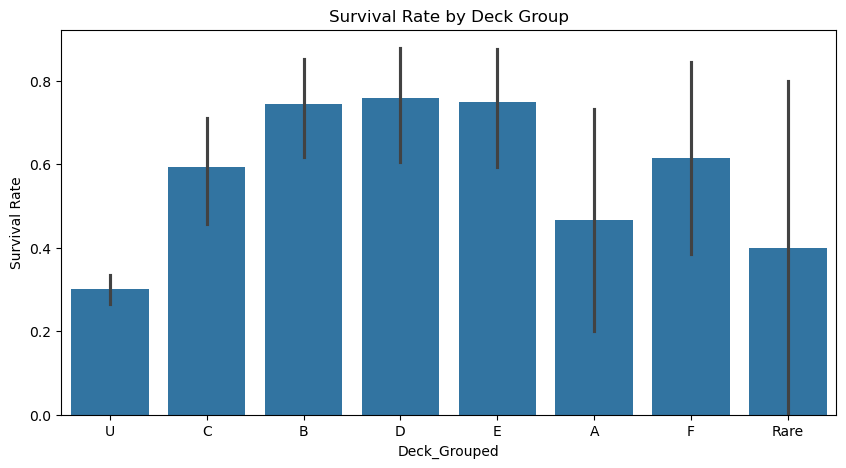

[Deck 그룹별 승객 수]
Deck_Grouped
U       687
C        59
B        47
D        33
E        32
A        15
F        13
Rare      5
Name: count, dtype: int64


In [17]:
# Cabin 첫 글자에서 Deck 추출
# - 결측치는 Unknown으로 처리합니다.
train['Deck'] = train['Cabin'].fillna('Unknown').str[0]

# 표본 수가 너무 적은 Deck는 Rare로 통합
deck_counts = train['Deck'].value_counts()
rare_decks = deck_counts[deck_counts < 10].index

train['Deck_Grouped'] = train['Deck'].replace(rare_decks, 'Rare')

# 시각화를 위한 순서 설정
deck_order = train['Deck_Grouped'].value_counts().index

plt.figure(figsize=(10, 5))
sns.barplot(data=train, x='Deck_Grouped', y='Survived', order=deck_order)
plt.title('Survival Rate by Deck Group')
plt.xlabel('Deck_Grouped')
plt.ylabel('Survival Rate')
plt.show()

print("[Deck 그룹별 승객 수]")
print(train['Deck_Grouped'].value_counts())


### 17. 추가 EDA 5. 다변량 교차분석으로 상호작용 확인

- 단일 변수만 보면 놓칠 수 있으므로, **`Sex × Pclass`**, **`Embarked × Pclass`**처럼
  두 변수를 함께 보면서 생존 패턴을 확인합니다.
- 이 과정은 트리 기반 모델의 적합성이나 interaction feature 설계 근거가 됩니다.


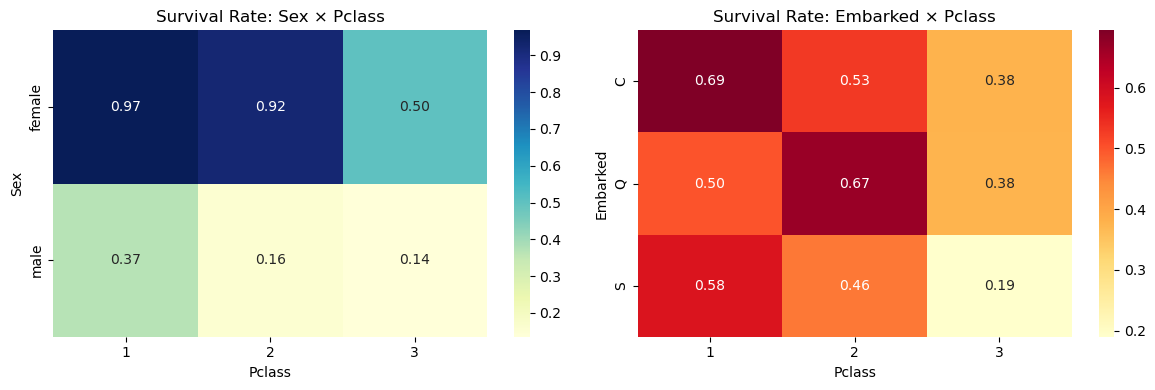

[Sex × Pclass 생존율]
Pclass      1      2      3
Sex                        
female  0.968  0.921  0.500
male    0.369  0.157  0.135

[Embarked × Pclass 생존율]
Pclass        1      2      3
Embarked                     
C         0.694  0.529  0.379
Q         0.500  0.667  0.375
S         0.583  0.463  0.190


In [18]:
# 1) Sex × Pclass 생존율 피벗 테이블
sex_pclass_pivot = train.pivot_table(
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean'
)

# 2) Embarked × Pclass 생존율 피벗 테이블
embarked_pclass_pivot = train.pivot_table(
    values='Survived',
    index='Embarked',
    columns='Pclass',
    aggfunc='mean'
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(sex_pclass_pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Survival Rate: Sex × Pclass')

plt.subplot(1, 2, 2)
sns.heatmap(embarked_pclass_pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Survival Rate: Embarked × Pclass')

plt.tight_layout()
plt.show()

print("[Sex × Pclass 생존율]")
print(sex_pclass_pivot.round(3))

print("\n[Embarked × Pclass 생존율]")
print(embarked_pclass_pivot.round(3))


### 18. 추가 EDA 6. 모델링 직전 전처리 후보 정리

- 지금까지의 EDA를 바탕으로, 각 변수에 어떤 처리를 적용할지 간단히 정리합니다.
- 이 셀은 이후 전처리/모델링 노트북으로 넘어갈 때 체크리스트로 사용할 수 있습니다.


In [19]:
# 모델링으로 바로 이어질 수 있도록 EDA 결과를 표 형태로 정리합니다.
eda_action_df = pd.DataFrame({
    'feature': [
        'Age',
        'Cabin',
        'Deck_Grouped',
        'Fare',
        'Embarked',
        'FamilySize / IsAlone',
        'Sex × Pclass'
    ],
    'EDA에서 확인한 포인트': [
        'Title, Pclass에 따라 연령 분포 차이가 큼',
        '결측이 매우 많지만 결측 여부 자체가 정보일 수 있음',
        '일부 Deck는 생존율 차이가 있지만 희소 레벨이 존재함',
        '왜도가 커서 로그 변환 효과가 큼',
        '항구별 생존율 차이가 존재함',
        '혼자 탑승 여부와 가족 규모가 생존과 관련됨',
        '두 변수의 상호작용 효과가 큼'
    ],
    '권장 처리': [
        'Title + Pclass 기준 중앙값 대체',
        '원본 Cabin은 제외하거나 HasCabin만 사용',
        'Rare / Unknown 통합 후 One-Hot Encoding 검토',
        'Fare_Log 사용 검토',
        '최빈값 대체 후 One-Hot Encoding',
        '둘 다 넣되 상관성 점검 또는 하나를 우선 사용',
        '트리 모델 활용 또는 interaction feature 고려'
    ]
})

print(eda_action_df)


                feature                    EDA에서 확인한 포인트  \
0                   Age    Title, Pclass에 따라 연령 분포 차이가 큼   
1                 Cabin    결측이 매우 많지만 결측 여부 자체가 정보일 수 있음   
2          Deck_Grouped  일부 Deck는 생존율 차이가 있지만 희소 레벨이 존재함   
3                  Fare               왜도가 커서 로그 변환 효과가 큼   
4              Embarked                  항구별 생존율 차이가 존재함   
5  FamilySize / IsAlone         혼자 탑승 여부와 가족 규모가 생존과 관련됨   
6          Sex × Pclass                 두 변수의 상호작용 효과가 큼   

                                     권장 처리  
0                 Title + Pclass 기준 중앙값 대체  
1             원본 Cabin은 제외하거나 HasCabin만 사용  
2  Rare / Unknown 통합 후 One-Hot Encoding 검토  
3                           Fare_Log 사용 검토  
4                최빈값 대체 후 One-Hot Encoding  
5               둘 다 넣되 상관성 점검 또는 하나를 우선 사용  
6       트리 모델 활용 또는 interaction feature 고려  
